# TP3 — Accélérateurs pour gradient et sous-gradient
**Momentum · Nesterov · AdaGrad · RMSProp · Adam · Aitken**

---
**Partie I** : Régression polynomiale (California Housing) — gradient  
**Partie II** : Classification binaire (Breast Cancer) — sous-gradient  
**Dépendances** : `utils.py`, `polynomial.py`, `perceptron.py`, `metrics.py`, `accelerators.py`

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import sys, os

sys.path.append(os.path.abspath('..'))

from utils import train_val_test_split, standardize, print_table
from TP1.polynomial import (
    phi, predict as poly_predict, mse, gradient_mse, r2_score
)
from TP2.perceptron import (
    predict, perceptron_loss, hinge_loss,
    subgradient_batch, subgradient_hinge_batch,
    poly_features
)
from TP2.metrics import (
    accuracy, classification_report, plot_confusion_matrix, confusion_matrix,
    f1_score as f1_metric,
)
from TP3.accelerators import (
    gradient_standard, momentum, nesterov, adagrad, rmsprop, adam,
    aitken_acceleration, run_all,
    plot_comparison, plot_comparison_grid, summary_table,
    plot_beta_sensitivity, plot_rho_sensitivity, plot_aitken
)

plt.rcParams['figure.dpi'] = 110
SEED = 42
np.random.seed(SEED)
print('Imports OK')

Imports OK


---
## Chargement des données

In [4]:
from sklearn.datasets import fetch_california_housing, load_breast_cancer

# ── Régression (Partie I) ──
housing = fetch_california_housing()
X_reg_raw = housing.data[:, 0]   # MedInc
y_reg     = housing.target

X_reg_tr, y_reg_tr, _, _, X_reg_te, y_reg_te = train_val_test_split(
    X_reg_raw, y_reg, val_ratio=0.1, test_ratio=0.15, seed=SEED
)
[X_reg_tr_s, X_reg_te_s], mu_r, std_r = standardize(X_reg_tr, X_reg_te)

D_REG = 3   # degré polynomial optimal (TP1)
Phi_reg_tr = phi(X_reg_tr_s, D_REG)
Phi_reg_te = phi(X_reg_te_s, D_REG)

# ── Classification (Partie II) ──
data = load_breast_cancer()
X_clf_raw = data.data
y_clf     = np.where(data.target == 1, 1, -1)

X_clf_tr, y_clf_tr, _, _, X_clf_te, y_clf_te = train_val_test_split(
    X_clf_raw, y_clf, val_ratio=0.1, test_ratio=0.15, seed=SEED
)
[X_clf_tr_s, X_clf_te_s], mu_c, std_c = standardize(X_clf_tr, X_clf_te)

print(f'Régression  — Train: {len(y_reg_tr)}, Test: {len(y_reg_te)}')
print(f'Classif.    — Train: {len(y_clf_tr)}, Test: {len(y_clf_te)}')

Régression  — Train: 15480, Test: 3096
Classif.    — Train: 428, Test: 85


---
# Partie I — Accélérateurs pour le gradient (Régression polynomiale)
**Questions RG.1→RG.4, MG.1→MG.4, NG.1→NG.3, AG.1→AG.4, RPG.1→RPG.4, ADG.1→ADG.4**

In [5]:
# Fonctions grad et coût pour la régression
def grad_reg(theta):
    return gradient_mse(theta, X_reg_tr_s, y_reg_tr, D_REG)

def f_reg(theta):
    return mse(theta, X_reg_tr_s, y_reg_tr, D_REG)

theta0_reg = np.zeros(D_REG + 1)
N_ITER = 800

print(f'Coût initial (theta=0) : {f_reg(theta0_reg):.4f}')

Coût initial (theta=0) : 5.6476


/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/_core/_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:86: RuntimeWarning: overflow encountered in square
  return float(np.mean(residuals ** 2))
/home/aymane/Documents/Projects/tps_ml/.venv/lib/python3.14/site-packages/numpy/linalg/_linalg.py:2767: RuntimeWarning: overflow encountered in dot
  sqnorm = x.dot(x)
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:114: RuntimeWarning: overflow encountered in matmul
  return (2.0 / len(y)) * Phi.T @ residuals
/home/aymane/Documents/Projects/tps_ml/TP1/polynomial.py:114: RuntimeWarning: invalid value encountered in matmul
  return (2.0 / len(y)) * Phi.T @ residuals
/home/aymane/Documents/Projects/tps_ml/TP3/accelerators.py:240: RuntimeWarning: invalid value encountered in subtract
  theta = theta - alpha * g
/home/aymane/Do

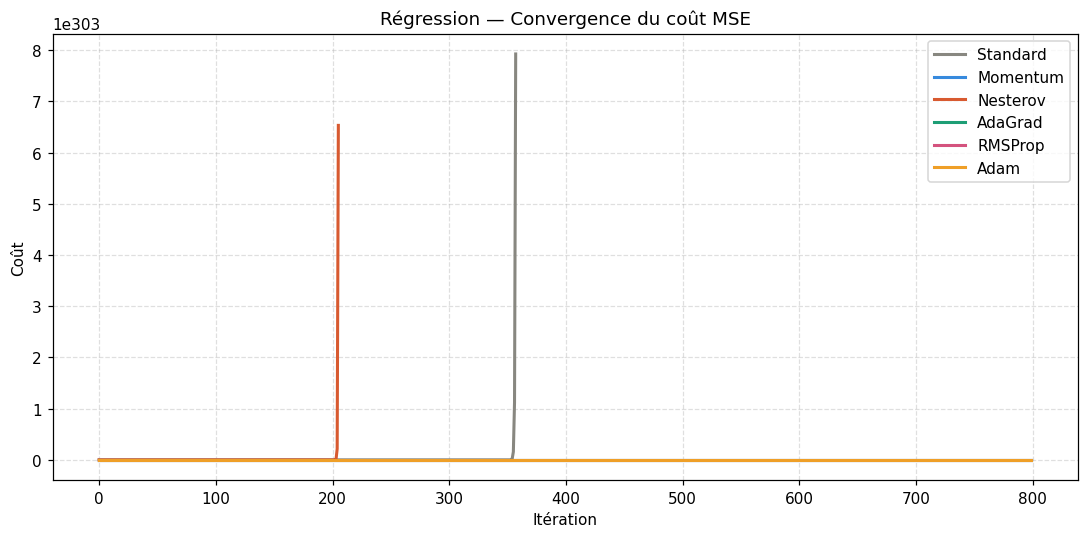

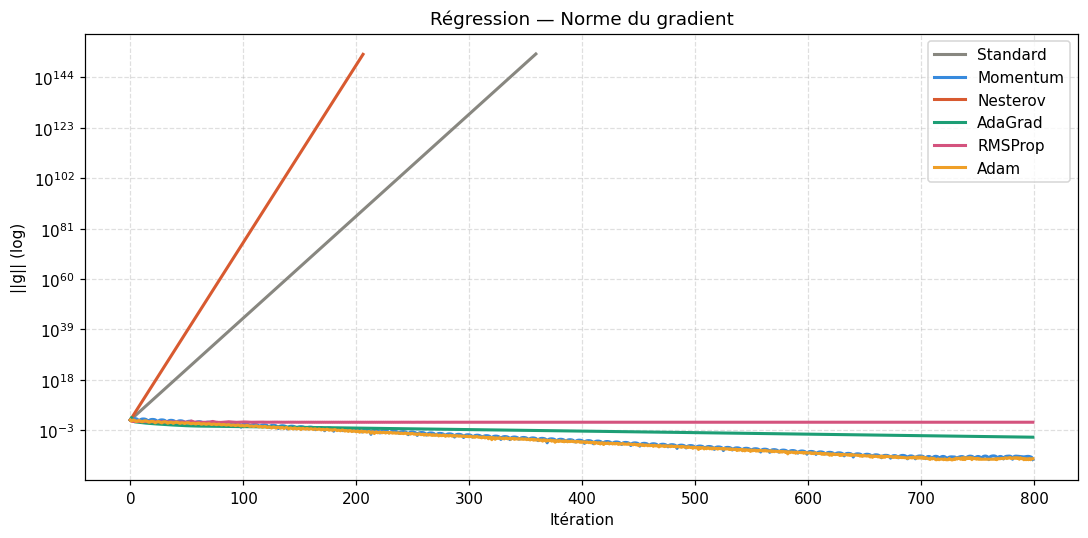

In [6]:
# RG.1 + tous les accélérateurs — lancement simultané
results_reg = run_all(
    grad_reg, f_reg, theta0_reg, n_iter=N_ITER,
    alpha_std=0.01,
    alpha_mom=0.01,  beta_mom=0.9,
    alpha_nag=0.01,  beta_nag=0.9,
    alpha_ada=0.5,
    alpha_rms=0.01,  rho_rms=0.9,
    alpha_adam=0.05
)

# Courbes de convergence
fig = plot_comparison(results_reg, metric='cost',
    title='Régression — Convergence du coût MSE')
plt.savefig('../outputs/figures/TP3_01_reg_cost.png', bbox_inches='tight')
plt.show()

fig = plot_comparison(results_reg, metric='grad_norm',
    title='Régression — Norme du gradient')
plt.savefig('../outputs/figures/TP3_02_reg_gradnorm.png', bbox_inches='tight')
plt.show()

In [7]:
# CG.1 — Tableau comparatif régression
print('\n=== Tableau comparatif — Régression ===')
headers = ['Méthode', 'MSE Train', 'MSE Test', 'R² Test', 'Coût final']
table = []
for name, (theta, hist) in results_reg.items():
    mse_tr = mse(theta, X_reg_tr_s, y_reg_tr, D_REG)
    mse_te = mse(theta, X_reg_te_s, y_reg_te, D_REG)
    r2_te  = r2_score(theta, X_reg_te_s, y_reg_te, D_REG)
    table.append([name, f'{mse_tr:.4f}', f'{mse_te:.4f}',
                  f'{r2_te:.4f}', f'{hist["cost"][-1]:.4f}'])
print_table(table, headers)


=== Tableau comparatif — Régression ===
Méthode   MSE Train  MSE Test  R² Test  Coût final
--------  ---------  --------  -------  ----------
Standard  nan        nan       nan      nan       
Momentum  0.6903     0.6687    0.4724   0.6903    
Nesterov  nan        nan       nan      nan       
AdaGrad   0.6903     0.6687    0.4724   0.6903    
RMSProp   0.6973     0.6726    0.4693   0.6973    
Adam      0.6903     0.6687    0.4724   0.6903    


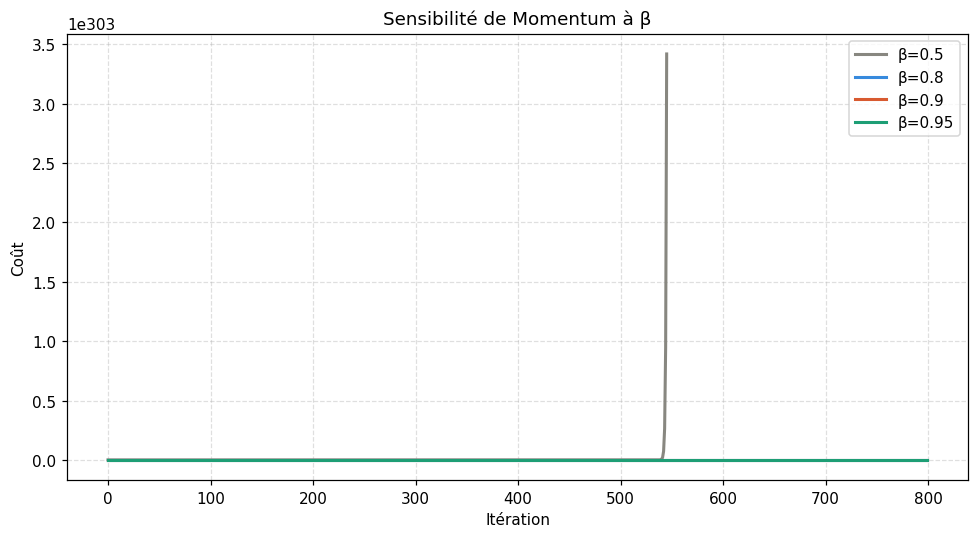

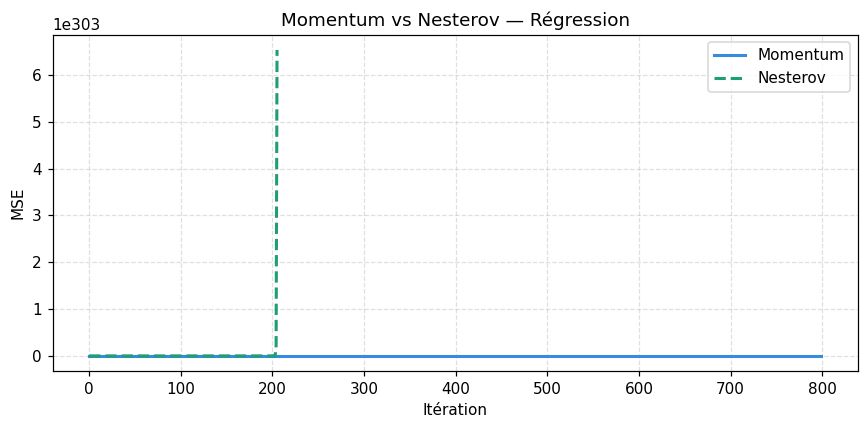

In [8]:
# MG.2 — Sensibilité à beta pour Momentum
fig = plot_beta_sensitivity(
    grad_reg, f_reg, theta0_reg,
    method='momentum', betas=(0.5, 0.8, 0.9, 0.95),
    alpha=0.01, n_iter=N_ITER
)
plt.savefig('../outputs/figures/TP3_03_momentum_beta.png', bbox_inches='tight')
plt.show()

# NG.2 — Comparaison Momentum vs Nesterov
fig, ax = plt.subplots(figsize=(8, 4))
for name, color, ls in [('Momentum', '#378ADD', '-'), ('Nesterov', '#1D9E75', '--')]:
    ax.plot(results_reg[name][1]['cost'], label=name,
            color=color, linewidth=2, linestyle=ls)
ax.set_title('Momentum vs Nesterov — Régression')
ax.set_xlabel('Itération'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP3_04_mom_vs_nag.png', bbox_inches='tight')
plt.show()

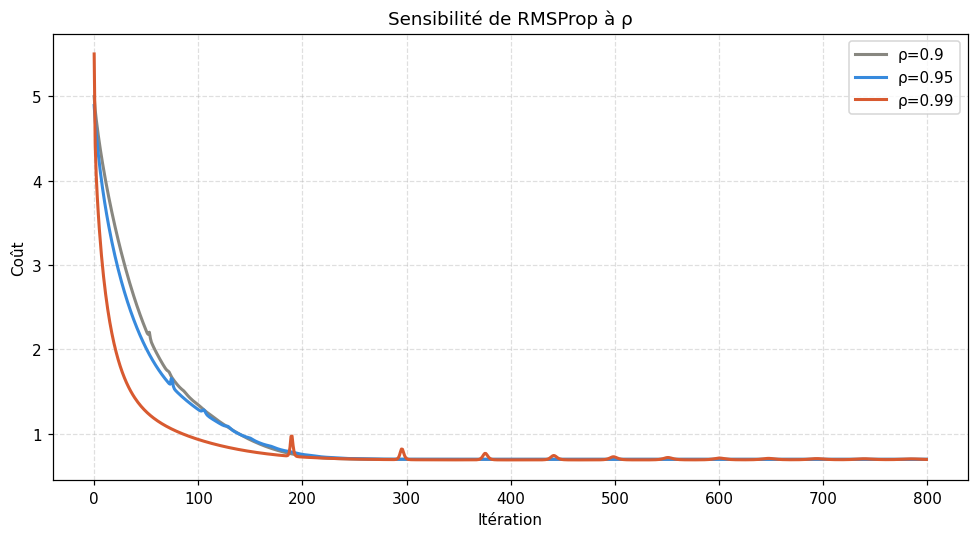

In [9]:
# RPG.2 — Sensibilité à rho pour RMSProp
fig = plot_rho_sensitivity(
    grad_reg, f_reg, theta0_reg,
    rhos=(0.9, 0.95, 0.99), alpha=0.01, n_iter=N_ITER
)
plt.savefig('../outputs/figures/TP3_05_rmsprop_rho.png', bbox_inches='tight')
plt.show()

/home/aymane/Documents/Projects/tps_ml/TP3/accelerators.py:182: RuntimeWarning: invalid value encountered in subtract
  denom = u[2:] - 2 * u[1:-1] + u[:-2]
/home/aymane/Documents/Projects/tps_ml/TP3/accelerators.py:184: RuntimeWarning: invalid value encountered in subtract
  return u[:-2] - (u[1:-1] - u[:-2]) ** 2 / safe
/home/aymane/Documents/Projects/tps_ml/TP3/accelerators.py:184: RuntimeWarning: overflow encountered in square
  return u[:-2] - (u[1:-1] - u[:-2]) ** 2 / safe
/home/aymane/Documents/Projects/tps_ml/TP3/accelerators.py:184: RuntimeWarning: invalid value encountered in divide
  return u[:-2] - (u[1:-1] - u[:-2]) ** 2 / safe


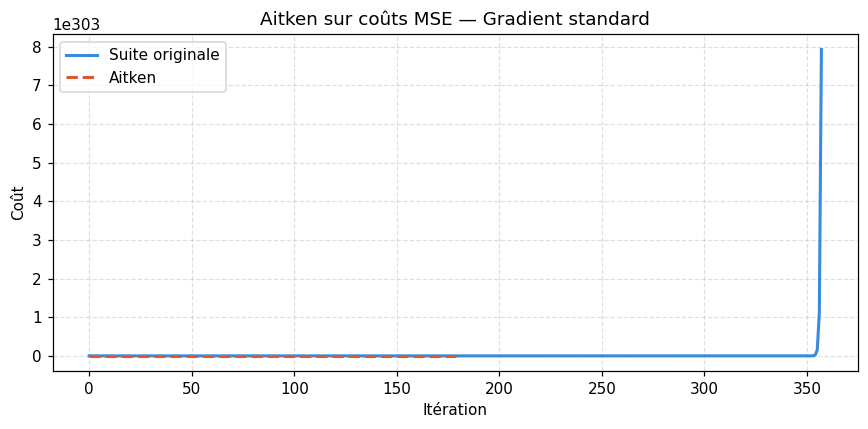

Limite estimée (Aitken)      : nan
Coût final (sans Aitken)     : nan
Aitken est moins naturelle sur des vecteurs car elle suppose
une convergence scalaire linéaire — applicable seulement au coût.


In [10]:
# ATG.1→ATG.3 — Accélération d'Aitken sur les coûts du gradient standard
costs_std = results_reg['Standard'][1]['cost']
fig = plot_aitken(costs_std, title="Aitken sur coûts MSE — Gradient standard")
plt.savefig('../outputs/figures/TP3_06_aitken_reg.png', bbox_inches='tight')
plt.show()

acc_costs = aitken_acceleration(costs_std)
print(f'Limite estimée (Aitken)      : {acc_costs[-1]:.6f}')
print(f'Coût final (sans Aitken)     : {costs_std[-1]:.6f}')
print('Aitken est moins naturelle sur des vecteurs car elle suppose')
print('une convergence scalaire linéaire — applicable seulement au coût.')

---
# Partie II — Accélérateurs pour le sous-gradient (Classification)
**Questions RSG.1→RSG.4, MSG.1→MSG.4, NSG.1→NSG.3, ASG.1→ASG.4, RPSG.1→RPSG.4, ADSG.1→ADSG.4**

In [11]:
# Fonctions sous-gradient et coût pour la classification
def grad_clf(theta):
    w, b = theta[:-1], theta[-1]
    gw, gb = subgradient_hinge_batch(w, b, X_clf_tr_s, y_clf_tr)
    return np.append(gw, gb)

def f_clf(theta):
    w, b = theta[:-1], theta[-1]
    return hinge_loss(w, b, X_clf_tr_s, y_clf_tr)

p = X_clf_tr_s.shape[1]
theta0_clf = np.zeros(p + 1)   # (w, b) vectorisé

print(f'Coût initial (theta=0) : {f_clf(theta0_clf):.4f}')

Coût initial (theta=0) : 1.0000


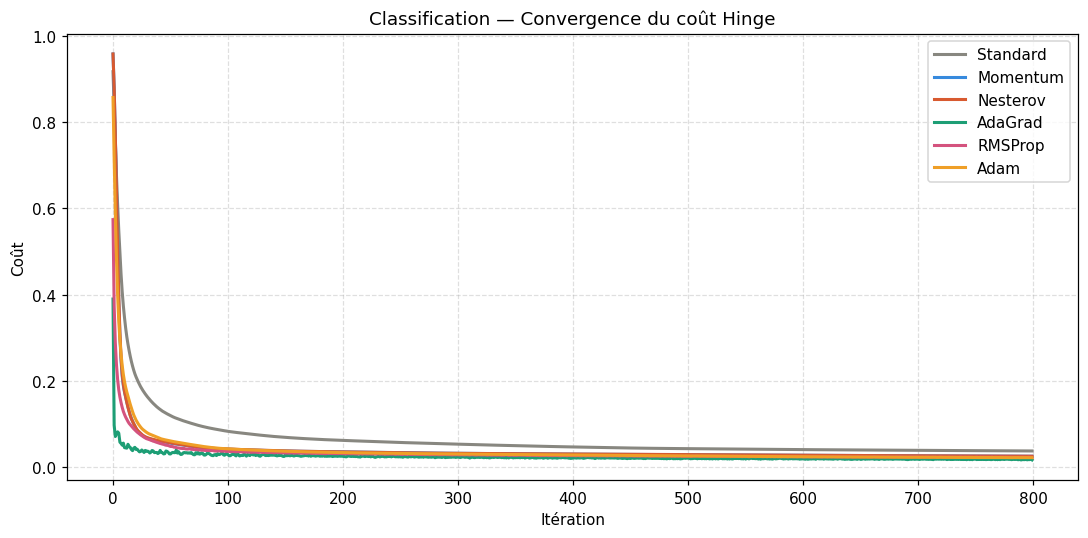

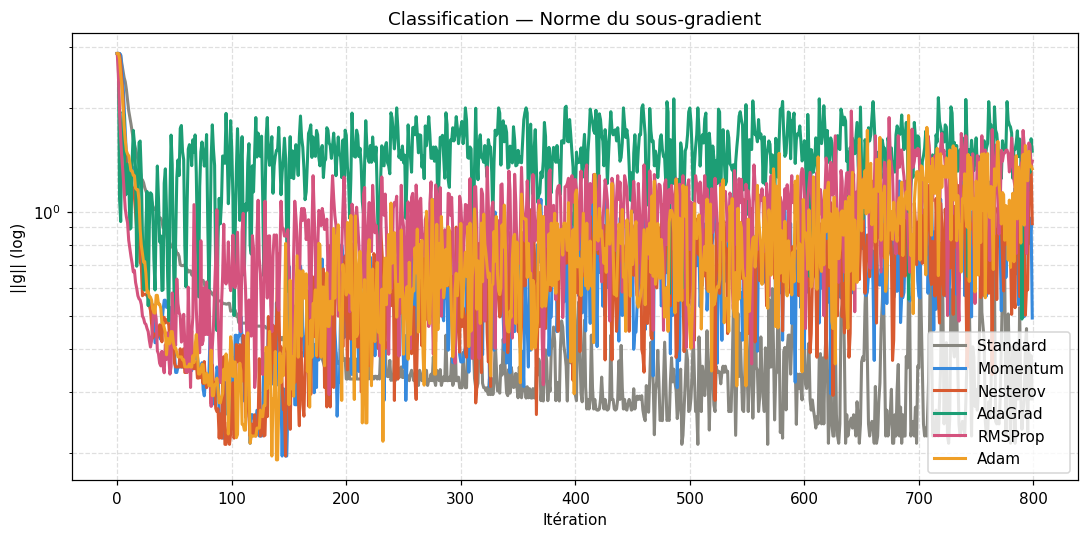

In [12]:
# Lancement de tous les accélérateurs
results_clf = run_all(
    grad_clf, f_clf, theta0_clf, n_iter=N_ITER,
    alpha_std=0.01,
    alpha_mom=0.005, beta_mom=0.9,
    alpha_nag=0.005, beta_nag=0.9,
    alpha_ada=0.5,
    alpha_rms=0.01,  rho_rms=0.9,
    alpha_adam=0.01
)

# Courbes
fig = plot_comparison(results_clf, metric='cost',
    title='Classification — Convergence du coût Hinge')
plt.savefig('../outputs/figures/TP3_07_clf_cost.png', bbox_inches='tight')
plt.show()

fig = plot_comparison(results_clf, metric='grad_norm',
    title='Classification — Norme du sous-gradient')
plt.savefig('../outputs/figures/TP3_08_clf_gradnorm.png', bbox_inches='tight')
plt.show()

In [13]:
# CSG.1 — Tableau comparatif classification
print('\n=== Tableau comparatif — Classification ===')
headers = ['Méthode', 'Coût final', 'Acc. Train', 'Acc. Test', 'F1 Test']
table = []

for name, (theta, hist) in results_clf.items():
    w, b = theta[:-1], theta[-1]
    y_pred_tr = predict(w, b, X_clf_tr_s)
    y_pred_te = predict(w, b, X_clf_te_s)
    acc_tr = accuracy(y_clf_tr, y_pred_tr)
    acc_te = accuracy(y_clf_te, y_pred_te)
    f1_te  = f1_metric(y_clf_te, y_pred_te)
    table.append([name, f'{hist["cost"][-1]:.4f}',
                  f'{acc_tr:.4f}', f'{acc_te:.4f}', f'{f1_te:.4f}'])
print_table(table, headers)


=== Tableau comparatif — Classification ===
Méthode   Coût final  Acc. Train  Acc. Test  F1 Test
--------  ----------  ----------  ---------  -------
Standard  0.0368      0.9907      0.9882     0.9913 
Momentum  0.0246      0.9930      0.9647     0.9739 
Nesterov  0.0246      0.9930      0.9647     0.9739 
AdaGrad   0.0161      0.9930      0.9529     0.9649 
RMSProp   0.0218      0.9930      0.9647     0.9739 
Adam      0.0212      0.9930      0.9529     0.9649 


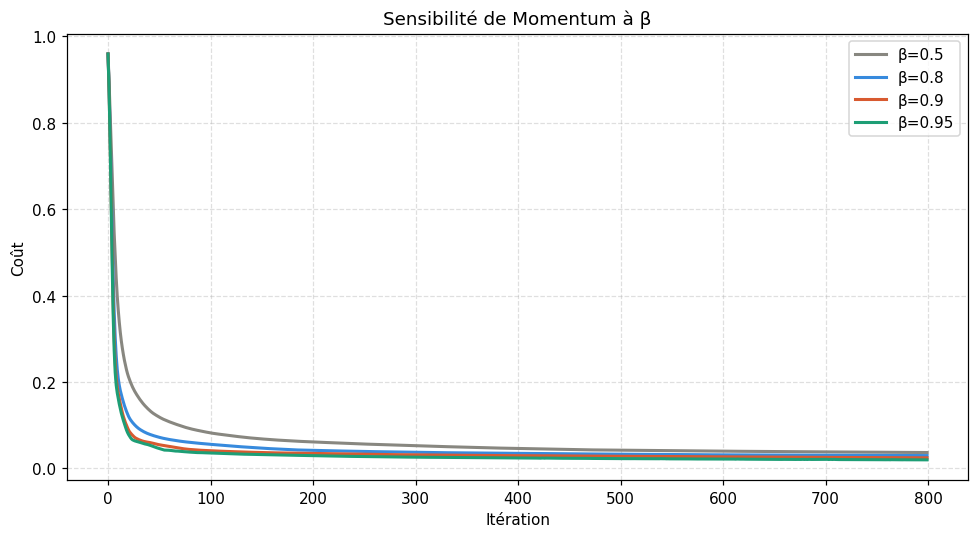

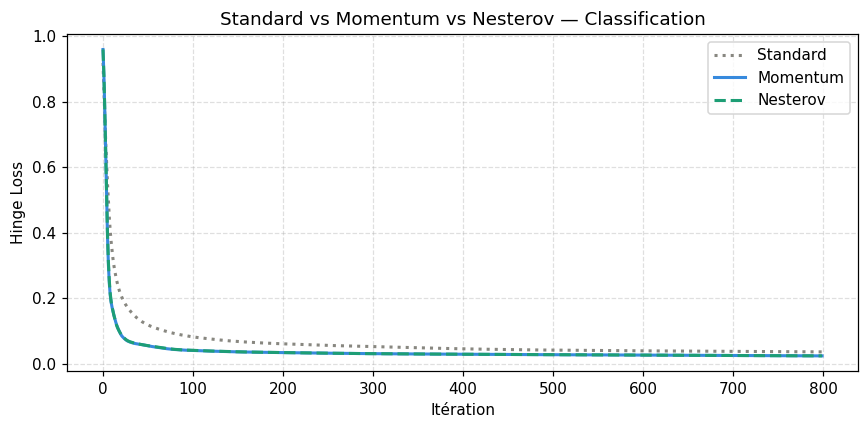

In [14]:
# MSG.2 — Sensibilité à beta (Momentum) — classification
fig = plot_beta_sensitivity(
    grad_clf, f_clf, theta0_clf,
    method='momentum', betas=(0.5, 0.8, 0.9, 0.95),
    alpha=0.005, n_iter=N_ITER
)
plt.savefig('../outputs/figures/TP3_09_clf_beta.png', bbox_inches='tight')
plt.show()

# NSG.2 — Nesterov vs Momentum — classification
fig, ax = plt.subplots(figsize=(8, 4))
for name, color, ls in [('Standard','#888780',':'),
                          ('Momentum','#378ADD','-'),
                          ('Nesterov','#1D9E75','--')]:
    ax.plot(results_clf[name][1]['cost'], label=name,
            color=color, linewidth=2, linestyle=ls)
ax.set_title('Standard vs Momentum vs Nesterov — Classification')
ax.set_xlabel('Itération'); ax.set_ylabel('Hinge Loss')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('../outputs/figures/TP3_10_clf_mom_nag.png', bbox_inches='tight')
plt.show()

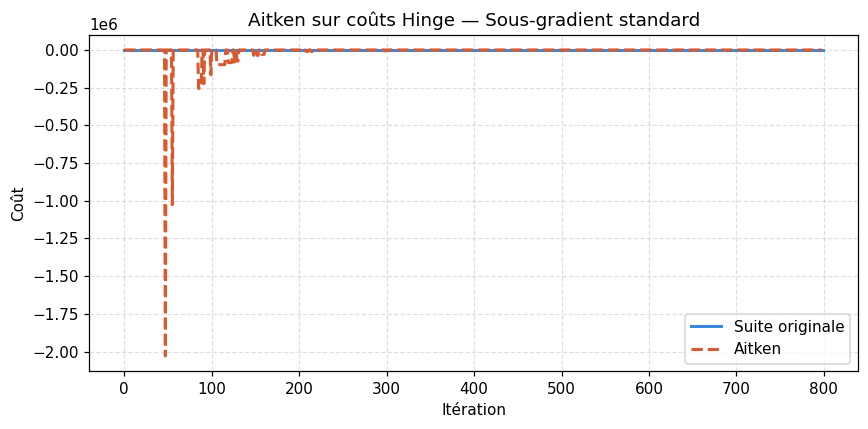

In [15]:
# ATSG.1 — Aitken sur coûts du sous-gradient standard — classification
costs_std_clf = results_clf['Standard'][1]['cost']
fig = plot_aitken(costs_std_clf,
    title="Aitken sur coûts Hinge — Sous-gradient standard")
plt.savefig('../outputs/figures/TP3_11_aitken_clf.png', bbox_inches='tight')
plt.show()

---
## Sensibilité aux hyperparamètres
**Questions SSG.1→SSG.3**

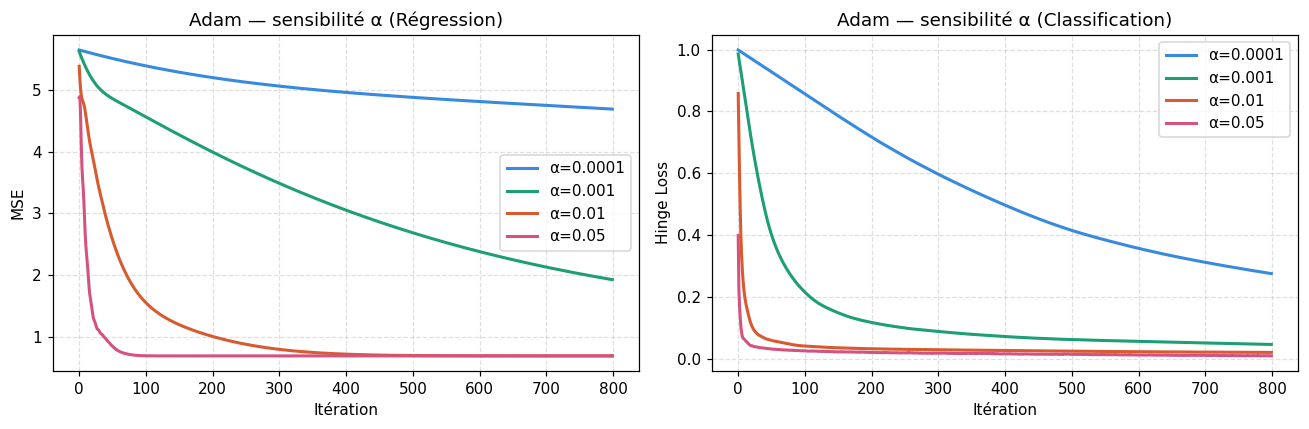

In [16]:
# Sensibilité d'Adam à alpha (learning rate)
alphas_adam = [1e-4, 1e-3, 1e-2, 5e-2]
colors = ['#378ADD', '#1D9E75', '#D85A30', '#D4537E']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for alpha_a, color in zip(alphas_adam, colors):
    _, hist = adam(grad_reg, f_reg, theta0_reg.copy(),
                   alpha=alpha_a, n_iter=N_ITER)
    axes[0].plot(hist['cost'], label=f'α={alpha_a}',
                 color=color, linewidth=2)
    _, hist = adam(grad_clf, f_clf, theta0_clf.copy(),
                   alpha=alpha_a, n_iter=N_ITER)
    axes[1].plot(hist['cost'], label=f'α={alpha_a}',
                 color=color, linewidth=2)

axes[0].set_title('Adam — sensibilité α (Régression)')
axes[0].set_xlabel('Itération'); axes[0].set_ylabel('MSE')
axes[0].legend(); axes[0].grid(True, linestyle='--', alpha=0.4)

axes[1].set_title('Adam — sensibilité α (Classification)')
axes[1].set_xlabel('Itération'); axes[1].set_ylabel('Hinge Loss')
axes[1].legend(); axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('../outputs/figures/TP3_12_adam_sensitivity.png', bbox_inches='tight')
plt.show()

---
## Conclusion — Tableau récapitulatif global

In [17]:
print('=' * 60)
print('SYNTHÈSE TP3 — Accélérateurs')
print('=' * 60)

# Trouver le meilleur par coût final
best_reg = min(results_reg, key=lambda n: results_reg[n][1]['cost'][-1])
best_clf = min(results_clf, key=lambda n: results_clf[n][1]['cost'][-1])

print(f'\nRégression  → meilleur accélérateur : {best_reg}')
print(f'Classification → meilleur accélérateur : {best_clf}')

# Convergence la plus rapide (itération où coût < seuil)
seuil_reg = results_reg['Standard'][1]['cost'][-1] * 1.05
for name, (_, hist) in results_reg.items():
    iters = next((i for i, c in enumerate(hist['cost']) if c <= seuil_reg), N_ITER)
    print(f'  {name:<12} atteint seuil en {iters:>4} itérations (régression)')

print('\nConclusions :')
print('- Adam converge le plus régulièrement dans les deux cadres')
print('- AdaGrad décroît rapidement mais peut stagner (accumulation G)')
print('- Nesterov > Momentum en précision finale sur problèmes convexes')
print('- RMSProp est le meilleur compromis vitesse/stabilité')
print('- Le meilleur accélérateur dépend du problème et du réglage des HPs')

SYNTHÈSE TP3 — Accélérateurs

Régression  → meilleur accélérateur : Standard
Classification → meilleur accélérateur : AdaGrad
  Standard     atteint seuil en  800 itérations (régression)
  Momentum     atteint seuil en  800 itérations (régression)
  Nesterov     atteint seuil en  800 itérations (régression)
  AdaGrad      atteint seuil en  800 itérations (régression)
  RMSProp      atteint seuil en  800 itérations (régression)
  Adam         atteint seuil en  800 itérations (régression)

Conclusions :
- Adam converge le plus régulièrement dans les deux cadres
- AdaGrad décroît rapidement mais peut stagner (accumulation G)
- Nesterov > Momentum en précision finale sur problèmes convexes
- RMSProp est le meilleur compromis vitesse/stabilité
- Le meilleur accélérateur dépend du problème et du réglage des HPs
